In [24]:
import duckdb
import numpy 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
con = duckdb.connect('../data/workload.duckdb')
videos = con.execute("""
    SELECT
        *
    FROM dim_videos_ml
""").df()
con.close()


In [3]:
videos

,video_id,media_title,video_type,video_subtype,media_type,media_series,total_hours,date_first,date_last,total_day_span,...,processing_date_first,processing_date_last,processing_total_day_span,processing_active_days,post_processing_date_first,post_processing_date_last,post_processing_total_day_span,post_processing_active_days,expected_length_mins,expected_complexity
0,3f1e15377df0aa1889f360c247df7a90,Elden Ring,Playthrough,Part 5,Video Games,Soulsborne Games,24.20,2023-02-13,2023-02-27,15,...,2023-02-13,2023-02-25,13,9,2023-02-24,2023-02-27,4,3,30,High
1,8b355e78a5e31e75061372e25b22d6c7,Elden Ring,Review,Demi Human Chief,Video Games,Soulsborne Games,8.02,2023-02-15,2023-02-16,2,...,2023-02-15,2023-02-16,2,2,2023-02-16,2023-02-16,1,1,10,Medium
2,da6e01691e06c291bc49a6dc16d9315e,Elden Ring,Review,Erdtree Burial Watchdog,Video Games,Soulsborne Games,8.42,2023-02-18,2023-03-02,13,...,2023-02-28,2023-03-02,3,3,2023-02-28,2023-03-02,3,2,10,Low
3,e63306ce56de41f88ed7de3e3623aad9,Elden Ring,Playthrough,Part 6,Video Games,Soulsborne Games,18.48,2023-03-06,2023-03-24,19,...,2023-03-07,2023-03-24,18,8,2023-03-07,2023-03-07,1,1,30,High
4,1050d995453283fca97699b97994f646,Elden Ring,Review,Mad Pumpkin Head,Video Games,Soulsborne Games,5.35,2023-03-08,2023-03-09,2,...,2023-03-08,2023-03-09,2,2,2023-03-08,2023-03-09,2,2,10,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,9c3615321462efc7c23e266c6cda9c34,Elden Ring,Playthrough,Stormhill,Video Games,Soulsborne Games,2.08,2023-12-01,2023-12-05,5,...,NaT,NaT,<NA>,0,NaT,NaT,<NA>,0,<NA>,NaN
121,07aaa1ef7086375408e5bc334fb5ffcb,Superman Movies,Essay,Superman and Lois Toxic Relationship,Movies,Superman Series,0.08,2025-07-24,2025-07-24,1,...,NaT,NaT,<NA>,0,NaT,NaT,<NA>,0,<NA>,NaN
122,2dc5ce63b41ffc9653a8b7efa67d1383,Halloween,Scene Breakdown,Judith Myers,Movies,Halloween Series,0.22,2025-11-01,2025-11-14,14,...,NaT,NaT,<NA>,0,NaT,NaT,<NA>,0,<NA>,NaN
123,795721116c538919e606697bf1b5a020,Marvel's Spiderman,Review,The Main Event,Video Games,Spiderman Series,1.02,2023-04-29,2023-04-29,1,...,2023-04-29,2023-04-29,1,1,NaT,NaT,<NA>,0,<NA>,NaN


In [4]:
videos.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   video_id                        125 non-null    str           
 1   media_title                     125 non-null    str           
 2   video_type                      125 non-null    str           
 3   video_subtype                   125 non-null    str           
 4   media_type                      125 non-null    str           
 5   media_series                    125 non-null    str           
 6   total_hours                     125 non-null    float64       
 7   date_first                      125 non-null    datetime64[us]
 8   date_last                       125 non-null    datetime64[us]
 9   total_day_span                  125 non-null    int64         
 10  active_days_worked              125 non-null    int64         
 11  hours_editing    

In [5]:
videos['hours_creation']=videos['hours_pre_processing']+videos['hours_processing']

In [6]:
videos['hours_creation']

0      23.08
1       7.50
2       7.30
3      18.27
4       4.72
       ...  
120     2.08
121     0.08
122     0.22
123     1.01
124     1.67
Name: hours_creation, Length: 125, dtype: float64

In [7]:
videos['expected_complexity'].value_counts(dropna=False)

expected_complexity
High         46
Medium       33
NaN          24
Low          13
Very High     9
Name: count, dtype: int64

In [15]:

remove_mask = (
    # Specific (title, type, subtype) combinations
    videos[['media_title', 'video_type', 'video_subtype']].apply(tuple, axis=1).isin({
        ('Elden Ring', 'Playthrough', 'Part 7'),
        ('Elden Ring', 'Review', 'Godrick the Grafted'),
        ('Elden Ring', 'Playthrough', 'Intro'),
        ('Elden Ring', 'Playthrough', 'Stormhill'),
        ('Elden Ring', 'Playthrough', 'Limgrave Dungeons'),
        ('Elden Ring', 'Playthrough', 'Lake Agheel'),
        ('Elden Ring', 'Playthrough', 'Fringefolk'),
        ('Grand Theft Auto V', 'Review', "Trevors Intro"),
        ('Elden Ring', 'Playthrough', 'Deaths 03'),
        ('Hitman WOA', 'Playthrough', 'Sapienza Master'),
        ('Hitman WOA', 'Playthrough', 'Paris Silenced Pistol'),
        ('Grand Theft Auto V', 'Review', "Trevor's Intro"),
        ('The Witcher 3', 'Rankings', 'Velen Main Quests'),
        ('Indiana Jones Movies', 'Rankings','Movie Series By Category'),
        ('Jurassic Park Movies', 'Rankings','Character Rankings'),
        ('Hitman WOA', 'Playthrough','Paris Bond'),
    })
    # Any row typed as Shorts or Essay (no complete videos in these categories)
    | videos['video_type'].isin(['Shorts', 'Essay', 'Stats'])
    # Entire titles that are incomplete
    | videos['media_title'].isin(['Terminator Movies', 'Man of Steel',"Marvel's Spiderman", "A Nightmare on Elm Street 2:  Freddy's Revenge"])
    # Halloween scene breakdown
    | ((videos['media_title'] == 'Halloween') & (videos['video_type'] == 'Scene Breakdown'))
)

print("Rows being removed:")
print(videos[remove_mask][['media_title', 'video_type', 'video_subtype']].to_string())
print(f"\nOriginal: {len(videos)} | Removed: {remove_mask.sum()} | Remaining: {len(videos) - remove_mask.sum()}")
videos_complete = videos[~remove_mask].reset_index(drop=True)


Rows being removed:
                                        media_title       video_type                         video_subtype
98   A Nightmare on Elm Street 2:  Freddy's Revenge           Review                              3 Things
100                                      Hitman WOA      Playthrough                            Paris Bond
101                                      Elden Ring      Playthrough                                 Intro
102                                      Elden Ring      Playthrough                           Lake Agheel
103                                      Elden Ring      Playthrough                            Fringefolk
104                              Grand Theft Auto V           Review                         Trevors Intro
105                                      Elden Ring           Review                   Godrick the Grafted
106                                      Elden Ring      Playthrough                             Deaths 03
107              

In [12]:
videos_complete['expected_complexity'].value_counts(dropna=False)

expected_complexity
High         46
Medium       33
Low          13
Very High     9
Name: count, dtype: int64

In [16]:
videos_complete['hours_creation'].describe()

count    99.000000
mean     17.046566
std       8.775578
min       4.720000
25%       9.610000
50%      15.780000
75%      23.230000
max      53.150000
Name: hours_creation, dtype: float64

<Axes: xlabel='hours_creation', ylabel='Count'>

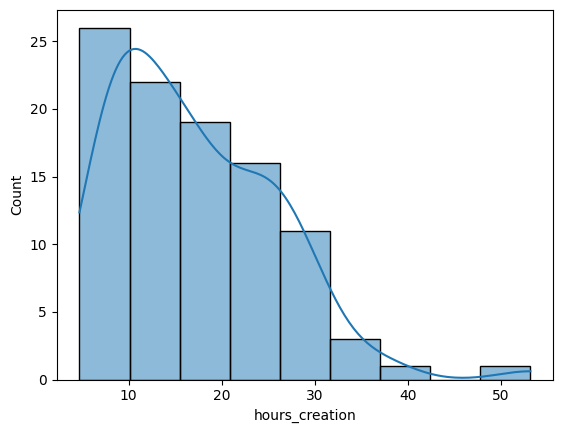

In [20]:
sns.histplot(videos_complete['hours_creation'], kde=True)

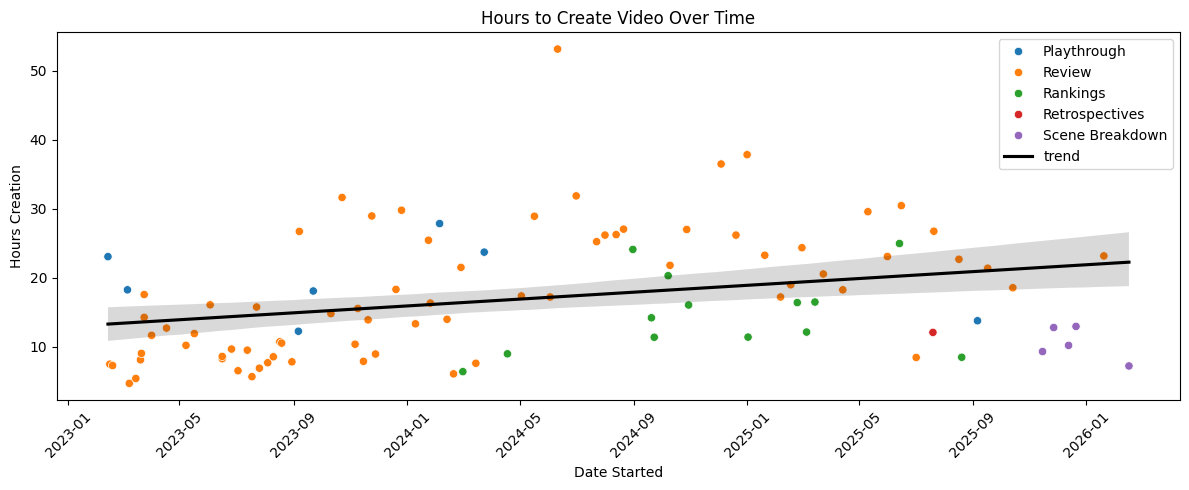

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

videos_plot = videos_complete.sort_values('date_first')

fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=videos_plot, x='date_first', y='hours_creation', hue='video_type', ax=ax)
sns.regplot(
    x=mdates.date2num(videos_plot['date_first']),
    y=videos_plot['hours_creation'],
    scatter=False, ax=ax, color='black', label='trend'
)

ax.set_title('Hours to Create Video Over Time')
ax.set_xlabel('Date Started')
ax.set_ylabel('Hours Creation')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


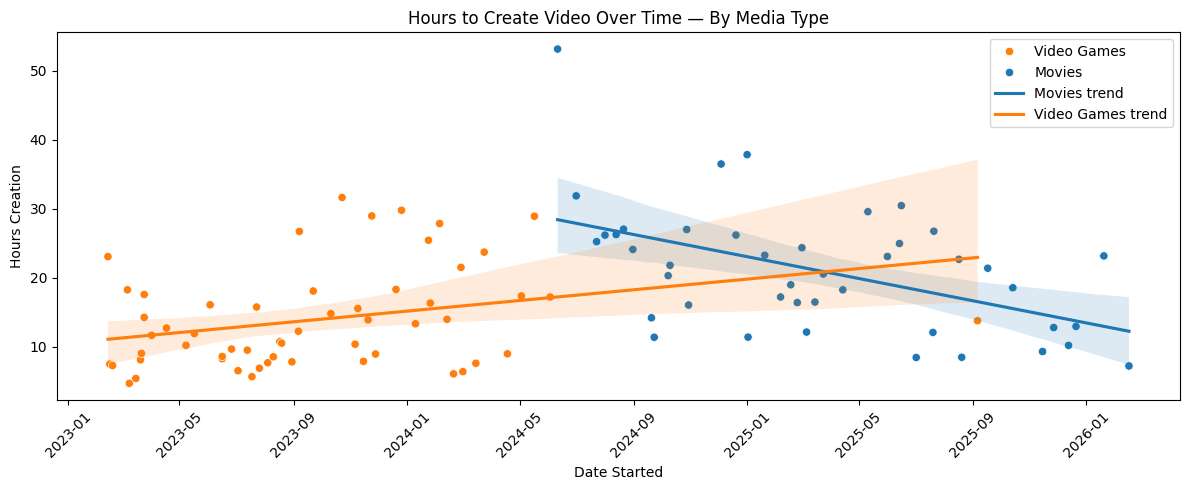

In [28]:
palette = {'Movies': '#1f77b4', 'Video Games': '#ff7f0e'}  # match seaborn defaults

fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=videos_plot, x='date_first', y='hours_creation', 
                hue='media_type', palette=palette, ax=ax)

for media, group in videos_plot.groupby('media_type'):
    sns.regplot(
        x=mdates.date2num(group['date_first']),
        y=group['hours_creation'],
        scatter=False, ax=ax, color=palette[media], label=f'{media} trend'
    )

ax.set_title('Hours to Create Video Over Time — By Media Type')
ax.set_xlabel('Date Started')
ax.set_ylabel('Hours Creation')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



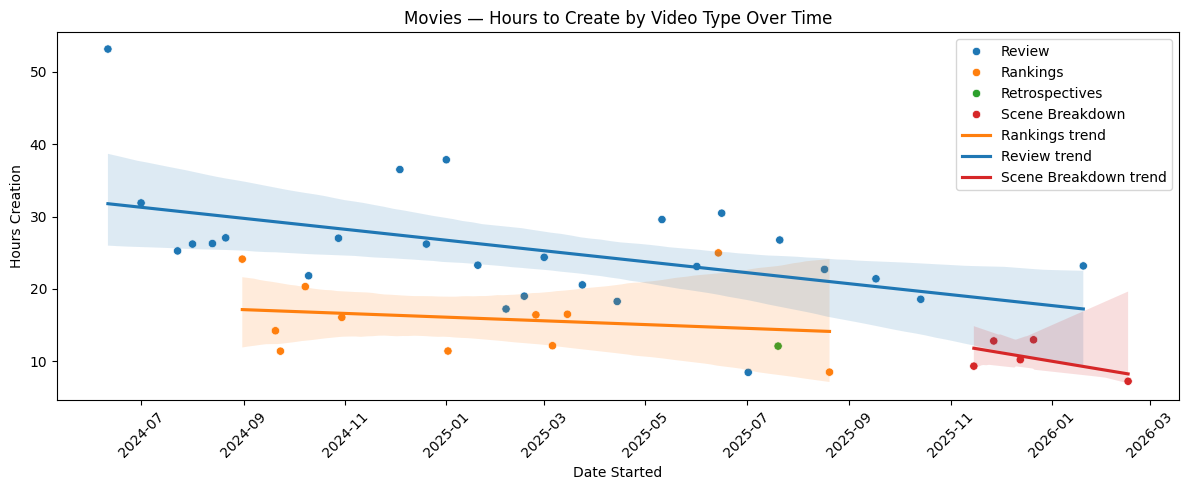

In [29]:
movie_videos = videos_plot[videos_plot['media_type'] == 'Movies']

palette_vtype = {t: c for t, c in zip(
    movie_videos['video_type'].unique(), 
    sns.color_palette(n_colors=movie_videos['video_type'].nunique())
)}

fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(data=movie_videos, x='date_first', y='hours_creation',
                hue='video_type', palette=palette_vtype, ax=ax)

for vtype, group in movie_videos.groupby('video_type'):
    if len(group) >= 5:  # only draw trend if enough points
        sns.regplot(
            x=mdates.date2num(group['date_first']),
            y=group['hours_creation'],
            scatter=False, ax=ax, color=palette_vtype[vtype], label=f'{vtype} trend'
        )

ax.set_title('Movies — Hours to Create by Video Type Over Time')
ax.set_xlabel('Date Started')
ax.set_ylabel('Hours Creation')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Next Step...relabel Jurassic World Short Review as a "Retrospective"
#Then in the Seed file, add in a new column:  "Unscripted" or "Not"

In [31]:
videos_complete[videos_complete['hours_script']<=0.5]

,video_id,media_title,video_type,video_subtype,media_type,media_series,total_hours,date_first,date_last,total_day_span,...,processing_date_last,processing_total_day_span,processing_active_days,post_processing_date_first,post_processing_date_last,post_processing_total_day_span,post_processing_active_days,expected_length_mins,expected_complexity,hours_creation
1,8b355e78a5e31e75061372e25b22d6c7,Elden Ring,Review,Demi Human Chief,Video Games,Soulsborne Games,8.02,2023-02-15,2023-02-16,2,...,2023-02-16,2,2,2023-02-16,2023-02-16,1,1,10,Medium,7.50
2,da6e01691e06c291bc49a6dc16d9315e,Elden Ring,Review,Erdtree Burial Watchdog,Video Games,Soulsborne Games,8.42,2023-02-18,2023-03-02,13,...,2023-03-02,3,3,2023-02-28,2023-03-02,3,2,10,Low,7.30
4,1050d995453283fca97699b97994f646,Elden Ring,Review,Mad Pumpkin Head,Video Games,Soulsborne Games,5.35,2023-03-08,2023-03-09,2,...,2023-03-09,2,2,2023-03-08,2023-03-09,2,2,10,Low,4.72
61,bd674ffccce566206028004a9edc50e5,Halloween,Rankings,Scene Rankings,Movies,Halloween Series,26.52,2024-08-31,2024-09-15,16,...,2024-09-15,16,12,2024-09-14,2024-09-15,2,2,25,Very High,24.12
62,78da5b087080f0172cc451093d53ca8b,Raiders of the Lost Ark,Rankings,Scene Rankings,Movies,Indiana Jones Series,15.52,2024-09-20,2024-10-08,19,...,2024-10-04,15,7,2024-10-06,2024-10-08,3,2,25,High,14.22
63,3491abd8444e3685eb586d6fb6789c11,Halloween 2,Rankings,Scene Rankings,Movies,Halloween Series,11.93,2024-09-23,2024-09-29,7,...,2024-09-29,7,5,2024-09-29,2024-09-29,1,1,25,High,11.40
64,8dd241d1d72a2d7442eea3c33c1a7b3b,Indiana Jones and the Temple of Doom,Rankings,Scene Rankings,Movies,Indiana Jones Series,21.00,2024-10-08,2024-11-03,27,...,2024-10-31,24,14,2024-11-03,2024-11-03,1,1,25,High,20.32
67,e97c009c1c994e933e98f60987aa42fe,Indiana Jones and the Last Crusade,Rankings,Scene Rankings,Movies,Indiana Jones Series,17.13,2024-10-30,2024-11-26,28,...,2024-11-25,27,11,2024-11-25,2024-11-26,2,2,20,High,16.07
71,795b1f194ba7b836b1688de650eebc2c,Indiana Jones and the Kingdom of the Crystal S...,Rankings,Scene Rankings,Movies,Indiana Jones Series,12.13,2025-01-02,2025-01-08,7,...,2025-01-08,7,5,2025-01-07,2025-01-08,2,2,20,Medium,11.42
75,ee270bd9ce82e930a52e19a9c9460d2e,Jurassic Park,Rankings,Scene Rankings,Movies,Jurassic Park Series,17.73,2025-02-24,2025-03-21,26,...,2025-03-10,15,11,2025-03-15,2025-03-21,7,4,20,High,16.42
